# **Penting**
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Hapus simbol pagar (#) jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan

# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [12]:
#Type your code here

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# **2. Memuat Dataset dari Hasil Clustering**
Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [13]:
# Gunakan dataset hasil clustering yang memiliki fitur Target
# Silakan gunakan dataset data_clustering jika tidak menerapkan Interpretasi Hasil Clustering [Advanced]
# Silakan gunakan dataset data_clustering_inverse jika menerapkan Interpretasi Hasil Clustering [Advanced]

data = pd.read_csv('/content/data_clustering.csv')

In [14]:
# Tampilkan 5 baris pertama dengan function head.
data.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Target
0,0.007554,2023-04-11 16:29:14,1,36,0,0.838710,0,0.244828,0.0,0.336790,2024-11-04 08:08:08,2
1,0.205368,2023-06-27 16:44:19,1,15,0,0.806452,0,0.451724,0.0,0.918049,2024-11-04 08:09:35,0
2,0.068840,2023-07-10 18:16:08,1,23,2,0.016129,3,0.158621,0.0,0.068578,2024-11-04 08:07:04,1
3,0.100636,2023-05-05 16:32:11,1,33,2,0.129032,3,0.051724,0.0,0.569170,2024-11-04 08:09:06,0
4,0.050192,2023-04-03 17:15:01,1,28,0,0.000000,3,0.558621,0.0,0.045677,2024-11-04 08:06:36,1


In [15]:
data = data.drop(columns=['TransactionDate',
                          'PreviousTransactionDate'
                      ])
data.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,0.007554,1,36,0,0.838710,0,0.244828,0.0,0.336790,2
1,0.205368,1,15,0,0.806452,0,0.451724,0.0,0.918049,0
2,0.068840,1,23,2,0.016129,3,0.158621,0.0,0.068578,1
3,0.100636,1,33,2,0.129032,3,0.051724,0.0,0.569170,0
4,0.050192,1,28,0,0.000000,3,0.558621,0.0,0.045677,1


# **3. Data Splitting**
Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [16]:
# Menggunakan train_test_split() untuk melakukan pembagian dataset.

# Memisahkan fitur (x) dan target (y)
X = data.drop(columns=['Target'])
y = data['Target']

# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# show bentuk set training dan set test untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(1708, 9), y_train=(1708,)
Test set shape: X_test=(427, 9), y_test=(427,)


# **4. Membangun Model Klasifikasi**
Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Menggunakan algoritma klasifikasi yaitu Decision Tree.
2. Latih model menggunakan data yang sudah dipisah.

In [17]:
# Buatlah model klasifikasi menggunakan Decision Tree
model_dt = DecisionTreeClassifier().fit(X_train, y_train)

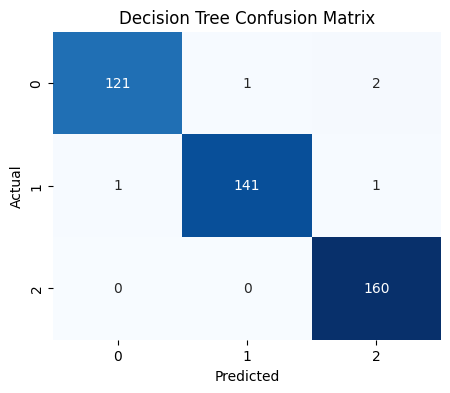

In [18]:
# Decison Tree
y_pred_dt = model_dt.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
# Menyimpan Model

import joblib
joblib.dump(model_dt, 'decision_tree_model.h5')

['decision_tree_model.h5']

# **5. Memenuhi Kriteria Skilled dan Advanced dalam Membangun Model Klasifikasi**



**Biarkan kosong jika tidak menerapkan kriteria skilled atau advanced**

In [20]:
# Melatih model menggunakan algoritma klasifikasi selain Decision Tree.
knn = KNeighborsClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)

In [21]:
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada seluruh algoritma yang sudah dibuat.

# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai dict
def evaluate_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai dict
def evaluate_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  # tn, fp, fn, tp = cm.ravel()
  results = {
      'Confusion Matrix': cm,
      'Accuracy': accuracy_score(y_test, y_pred),
      'Precision': precision_score(y_test, y_pred, average='macro'),
      'Recall': recall_score(y_test, y_pred, average='macro'),
      'F1-Score': f1_score(y_test, y_pred, average='macro')

  }
  return results

# Evaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(model_dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test),
}

# Membuat dataframe untuk menringkat hasil
summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

# Isi dataframe dengan hasil
rows = []
for model_name, metrics in results.items():
  rows.append({
      'Model': model_name,
      'Accuracy': metrics['Accuracy'],
      'Precision': metrics['Precision'],
      'Recall': metrics['Recall'],
      'F1-Score': metrics['F1-Score']
    })

# Konversi daftar dict ke dataframe
summary_df = pd.DataFrame(rows)

# Show dataframe
print(summary_df)

                          Model  Accuracy  Precision    Recall  F1-Score
0     K-Nearest Neighbors (KNN)  0.807963   0.811352  0.807468  0.806244
1            Decision Tree (DT)  0.988290   0.988785  0.987273  0.987975
2            Random Forest (RF)  0.983607   0.982809  0.983354  0.983074
3  Support Vector Machine (SVM)  0.758782   0.760256  0.762451  0.759164
4              Naive Bayes (NB)  0.948478   0.948249  0.948885  0.947185


In [22]:
# Menyimpan Model Selain Decision Tree
# Model ini bisa lebih dari satu
import joblib
joblib.dump(knn, 'explore_knn_classification.h5')

['explore_knn_classification.h5']

In [23]:
joblib.dump(rf, 'explore_random_forest_classification.h5')

['explore_random_forest_classification.h5']

### **Analisis Hasil Evaluasi Model**

1. **K-Nearest Neighbors (KNN)**

   * **Accuracy**: 80.80%
   * **Precision**: 81.14%
   * **Recall**: 80.75%
   * **F1-Score**: 80.62%

   **Analisis**: KNN menunjukkan performa yang cukup baik dan seimbang pada precision dan recall, mengindikasikan model mampu mengenali kelas-kelas dengan tingkat kesalahan yang masih wajar. Model ini cocok digunakan pada data yang tidak terlalu besar, namun dapat menjadi kurang optimal jika distribusi data tidak seragam atau terdapat banyak noise.

2. **Decision Tree (DT)**

   * **Accuracy**: 98.83%
   * **Precision**: 98.88%
   * **Recall**: 98.73%
   * **F1-Score**: 98.80%

   **Analisis**: Decision Tree menunjukkan performa yang sangat tinggi. Semua metrik berada di atas 98%, menandakan model mengenali hampir semua pola dengan sangat baik. Namun, ada potensi **overfitting**, terutama jika model tidak diuji pada data yang benar-benar baru.

3. **Random Forest (RF)**

   * **Accuracy**: 98.36%
   * **Precision**: 98.28%
   * **Recall**: 98.34%
   * **F1-Score**: 98.31%

   **Analisis**: Random Forest mendekati performa Decision Tree, namun sedikit lebih rendah. Model ini unggul dalam mengurangi risiko overfitting dibandingkan pohon keputusan tunggal karena menggunakan metode ensemble. Cocok untuk implementasi produksi dengan kebutuhan akurasi tinggi dan stabilitas yang lebih baik.

4. **Support Vector Machine (SVM)**

   * **Accuracy**: 75.88%
   * **Precision**: 76.03%
   * **Recall**: 76.25%
   * **F1-Score**: 75.92%

   **Analisis**: SVM memiliki performa sedang dibandingkan model lainnya. Meski precision dan recall relatif seimbang, akurasinya jauh lebih rendah. Hal ini bisa disebabkan oleh ketidaksesuaian kernel atau sensitivitas terhadap skala fitur. Model ini mungkin lebih cocok untuk data yang sudah sangat terstruktur dan terstandarisasi.

5. **Naive Bayes (NB)**

   * **Accuracy**: 94.85%
   * **Precision**: 94.82%
   * **Recall**: 94.89%
   * **F1-Score**: 94.72%

   **Analisis**: Naive Bayes memberikan hasil yang cukup baik, dengan precision dan recall yang sangat seimbang. Meskipun asumsi independensi fitur sering kali tidak sepenuhnya terpenuhi, model ini tetap mampu memberikan performa yang stabil dan cepat dalam pelatihan, cocok untuk baseline atau aplikasi real-time dengan keterbatasan komputasi.

---

### **Kesimpulan:**

* **Decision Tree** dan **Random Forest** menjadi model dengan performa terbaik dan sangat akurat.
* **Naive Bayes** tampil cukup kompeten meski tidak seakurat DT dan RF, namun sangat efisien dari sisi komputasi.
* **KNN** memberikan performa yang baik, namun dapat sensitif terhadap skala dan distribusi data.
* **SVM** memiliki performa terendah dalam uji ini dan mungkin perlu disesuaikan parameter atau jenis kernel-nya agar hasilnya lebih optimal.

---

### **Rekomendasi:**

* Jika menginginkan **kombinasi akurasi tinggi dan stabilitas**, gunakan **Random Forest**.
* Untuk model yang lebih sederhana dengan hasil sangat baik, **Decision Tree** masih layak digunakan, dengan catatan evaluasi overfitting.
* **Naive Bayes** cocok untuk kebutuhan sistem cepat dengan toleransi performa sedang.
* Hindari **SVM** sebagai opsi utama untuk data ini, kecuali dilakukan optimasi lebih lanjut.
* **KNN** dapat dipilih jika model interpretable dan tidak terlalu kompleks dibutuhkan.

---

Hyperparameter Tuning Model

Pilih salah satu algoritma yang ingin Anda tuning

In [24]:
# Lakukan Hyperparameter Tuning dan Latih ulang.

In [25]:
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada algoritma yang sudah dituning.

In [26]:
# Menyimpan Model hasil tuning
# import joblib
# joblib.dump(model_dt, 'tuning_classification.h5')